# Experiment 1: Train a DNN to try to identify to which user a given EEG signal belongs to

The main hypotesis is that the Users that are more similar in terms of their EEG signals will be more difficult to be identified by the DNN, while the Users that are more different will be easier to be identified. Using a confusion matrix, we can identify which Users are more similar and which are more different.

So when training for SSVEP BCIs, we can use this information to select the Users that are more similar to the target User, in order to improve the performance of the BCI.


In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = Path("/home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dnn import SSVEPDNN
try:
    from braindecode.models import EEGNet
except Exception:
    EEGNet = None

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# --- Experiment Configuration ---
# Options: "DNN" or "EEGNET"
MODEL_NAME = "DNN"

# Training hyperparameters
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_EVAL = 64
NUM_EPOCHS = 100
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.01

## Users train

- Set `MODEL_NAME` in the config cell to `"DNN"` or `"EEGNET"`.
- Run cells in order from top to bottom.
- Session split is fixed as: 4 sessions for training, 1 session for validation, and 1 session for testing.

In [4]:
# --- Data Preparation ---
from benchmark_dataset import load_data_from_users, load_freq_phase, build_tensors_no_cca
from cross_subject_utils import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
from ssvep_shared import filter_signals_subbands

# Configuration
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
seed = 42
torch.cuda.manual_seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)

sample_rate = 250
delay = 160
occipital_electrodes = np.array([47, 53, 54, 55, 56, 57, 60, 61, 62])
users = list(range(1, 36))
num_users = len(users)

frequencias, _ = load_freq_phase()
frequencias_desejadas = frequencias[:]
indices = [np.where(frequencias == freq)[0][0] for freq in frequencias_desejadas]

tamanho_da_janela_seg = 1.0
tamanho_da_janela = int(np.ceil(tamanho_da_janela_seg * sample_rate))

# Load data only if not already in memory
print("Loading data...")

all_data = load_data_from_users(
    users=users,
    dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
    visual_delay=delay,
    filter_bandpass=False,
    apply_car=True,
    car_reference_channels=occipital_electrodes,
    car_target_channels=occipital_electrodes,
    sample_rate=sample_rate,
    normalize=True,
)

# Session split: 4 sessions for train, 1 for validation, 1 for test
num_sessions = 6
train_sessions = [0, 1, 2, 3]
val_session = 4
test_session = 5

print(f"Using sessions {train_sessions} for training, session {val_session} for validation, and session {test_session} for testing")
print(f"Number of users (classes): {num_users}")

# Split data into train/val/test by session
train_data_all = []
val_data_all = []
test_data_all = []
train_labels_user = []
val_labels_user = []
test_labels_user = []

for user_idx, user_data in enumerate(all_data):
    # user_data shape: (channels, samples, freqs, trials=6)
    num_channels, num_samples, num_freqs, num_trials = user_data.shape

    # Train: sessions 0-3
    train_trials = user_data[:, :, :, train_sessions]  # (ch, samples, freqs, 4)
    # Validation: session 4
    val_trials = user_data[:, :, :, val_session:val_session+1]  # (ch, samples, freqs, 1)
    # Test: session 5
    test_trials = user_data[:, :, :, test_session:test_session+1]  # (ch, samples, freqs, 1)

    for freq_idx in indices:
        for trial_idx in range(len(train_sessions)):
            signal = train_trials[occipital_electrodes, :tamanho_da_janela, freq_idx, trial_idx]
            filtered = filter_signals_subbands(
                signal[np.newaxis, :, :],  # (1, channels, samples)
                sampling_rate=sample_rate,
                subban_no=3,
            )  # (1, subbands, channels, samples)
            train_data_all.append(filtered[0])  # (subbands, channels, samples)
            train_labels_user.append(user_idx)

        for trial_idx in range(1):
            signal = val_trials[occipital_electrodes, :tamanho_da_janela, freq_idx, trial_idx]
            filtered = filter_signals_subbands(
                signal[np.newaxis, :, :],
                sampling_rate=sample_rate,
                subban_no=3,
            )
            val_data_all.append(filtered[0])
            val_labels_user.append(user_idx)

        for trial_idx in range(1):
            signal = test_trials[occipital_electrodes, :tamanho_da_janela, freq_idx, trial_idx]
            filtered = filter_signals_subbands(
                signal[np.newaxis, :, :],
                sampling_rate=sample_rate,
                subban_no=3,
            )
            test_data_all.append(filtered[0])
            test_labels_user.append(user_idx)

X_train = torch.tensor(np.array(train_data_all), dtype=torch.float32).to(device)
X_val = torch.tensor(np.array(val_data_all), dtype=torch.float32).to(device)
X_test = torch.tensor(np.array(test_data_all), dtype=torch.float32).to(device)
Y_train = torch.tensor(train_labels_user, dtype=torch.long).to(device)
Y_val = torch.tensor(val_labels_user, dtype=torch.long).to(device)
Y_test = torch.tensor(test_labels_user, dtype=torch.long).to(device)

print(f"X_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_val: {X_val.shape}, Y_val: {Y_val.shape}")
print(f"X_test: {X_test.shape}, Y_test: {Y_test.shape}")

Loading data...


Carregando dados dos usuarios: 100%|██████████| 35/35 [01:31<00:00,  2.60s/it]


Using sessions [0, 1, 2, 3] for training, session 4 for validation, and session 5 for testing
Number of users (classes): 35
X_train: torch.Size([5600, 3, 9, 250]), Y_train: torch.Size([5600])
X_val: torch.Size([1400, 3, 9, 250]), Y_val: torch.Size([1400])
X_test: torch.Size([1400, 3, 9, 250]), Y_test: torch.Size([1400])


In [5]:
# --- Model Definition ---
class EEGNetWithSubbandMerge(nn.Module):
    """Merge subbands with a learnable 1x1 conv, then run EEGNet."""

    def __init__(self, subbands, n_chans, n_outputs, n_times, kernel_length, F1=8, D=2, drop_prob=0.25):
        super().__init__()
        self.subband_combination = nn.Conv2d(subbands, 1, kernel_size=(1, 1), bias=False)
        with torch.no_grad():
            self.subband_combination.weight.fill_(1.0 / subbands)

        self.eegnet = EEGNet(
            n_chans=n_chans,
            n_outputs=n_outputs,
            n_times=n_times,
            kernel_length=kernel_length,
            F1=F1,
            D=D,
            drop_prob=drop_prob,
        )

    def forward(self, x):
        # x: [batch, subbands, channels, time]
        x = self.subband_combination(x)  # [batch, 1, channels, time]
        x = x.squeeze(1)  # [batch, channels, time]
        return self.eegnet(x)


def build_model(model_name: str):
    model_name = model_name.upper()
    if model_name == "DNN":
        return SSVEPDNN(
            num_classes=num_users,
            channels=len(occipital_electrodes),
            samples=tamanho_da_janela,
            subbands=3,
            first_dropout=0.1,
            second_dropout=0.1,
            third_dropout=0.95,
        ).to(device)

    if model_name == "EEGNET":
        if EEGNet is None:
            raise ImportError(
                "EEGNet is unavailable. Install braindecode in this environment to use MODEL_NAME='EEGNET'."
            )
        return EEGNetWithSubbandMerge(
            subbands=3,
            n_chans=len(occipital_electrodes),
            n_outputs=num_users,
            n_times=tamanho_da_janela,
            kernel_length=(sample_rate // 2),
            F1=8,
            D=2,
            drop_prob=0.25,
        ).to(device)

    raise ValueError(f"Unknown MODEL_NAME: {model_name}. Use 'DNN' or 'EEGNET'.")


model = build_model(MODEL_NAME)
print(f"Using model: {MODEL_NAME.upper()}")

# --- Training Setup ---
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=BATCH_SIZE_TRAIN, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=BATCH_SIZE_EVAL, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test, Y_test), batch_size=BATCH_SIZE_EVAL, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# --- Training Loop ---
best_val_acc = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.inference_mode():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Val Acc: {val_acc:.4f} (Best: {best_val_acc:.4f})")

Using model: DNN


/home/mateuschinelatto/miniforge3/envs/bci/lib/python3.12/site-packages/torch/nn/modules/conv.py:543: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1031.)
  return F.conv2d(


Epoch 1/100 - Val Acc: 0.0786 (Best: 0.0786)
Epoch 25/100 - Val Acc: 0.9100 (Best: 0.9214)
Epoch 50/100 - Val Acc: 0.9186 (Best: 0.9236)
Epoch 75/100 - Val Acc: 0.9329 (Best: 0.9407)
Epoch 100/100 - Val Acc: 0.9386 (Best: 0.9407)


Test Accuracy: 0.9243


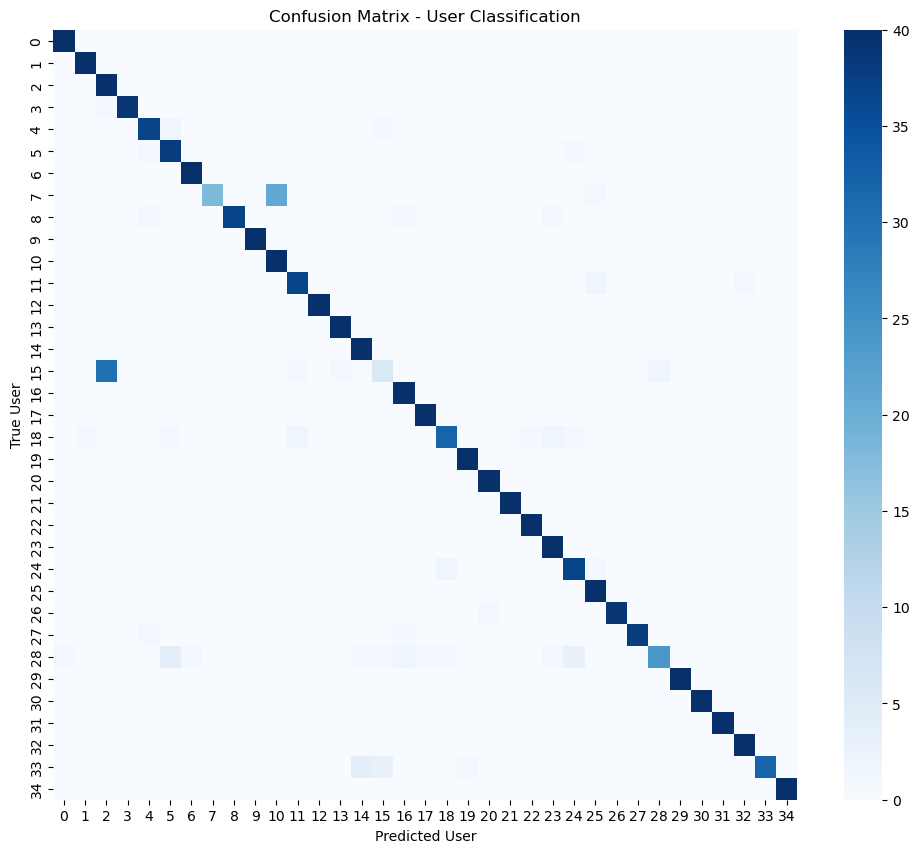

In [6]:
# --- Evaluation and Visualization ---
# Load best model and evaluate
model.load_state_dict(best_model_state)
model.eval()

all_preds = []
all_labels = []
with torch.inference_mode():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Compute accuracy and confusion matrix
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", fmt="d")
plt.title("Confusion Matrix - User Classification")
plt.xlabel("Predicted User")
plt.ylabel("True User")
plt.show()

Extracting train features...
Extracting test features...
Features shape: (1400, 15000), Labels shape: (1400,)


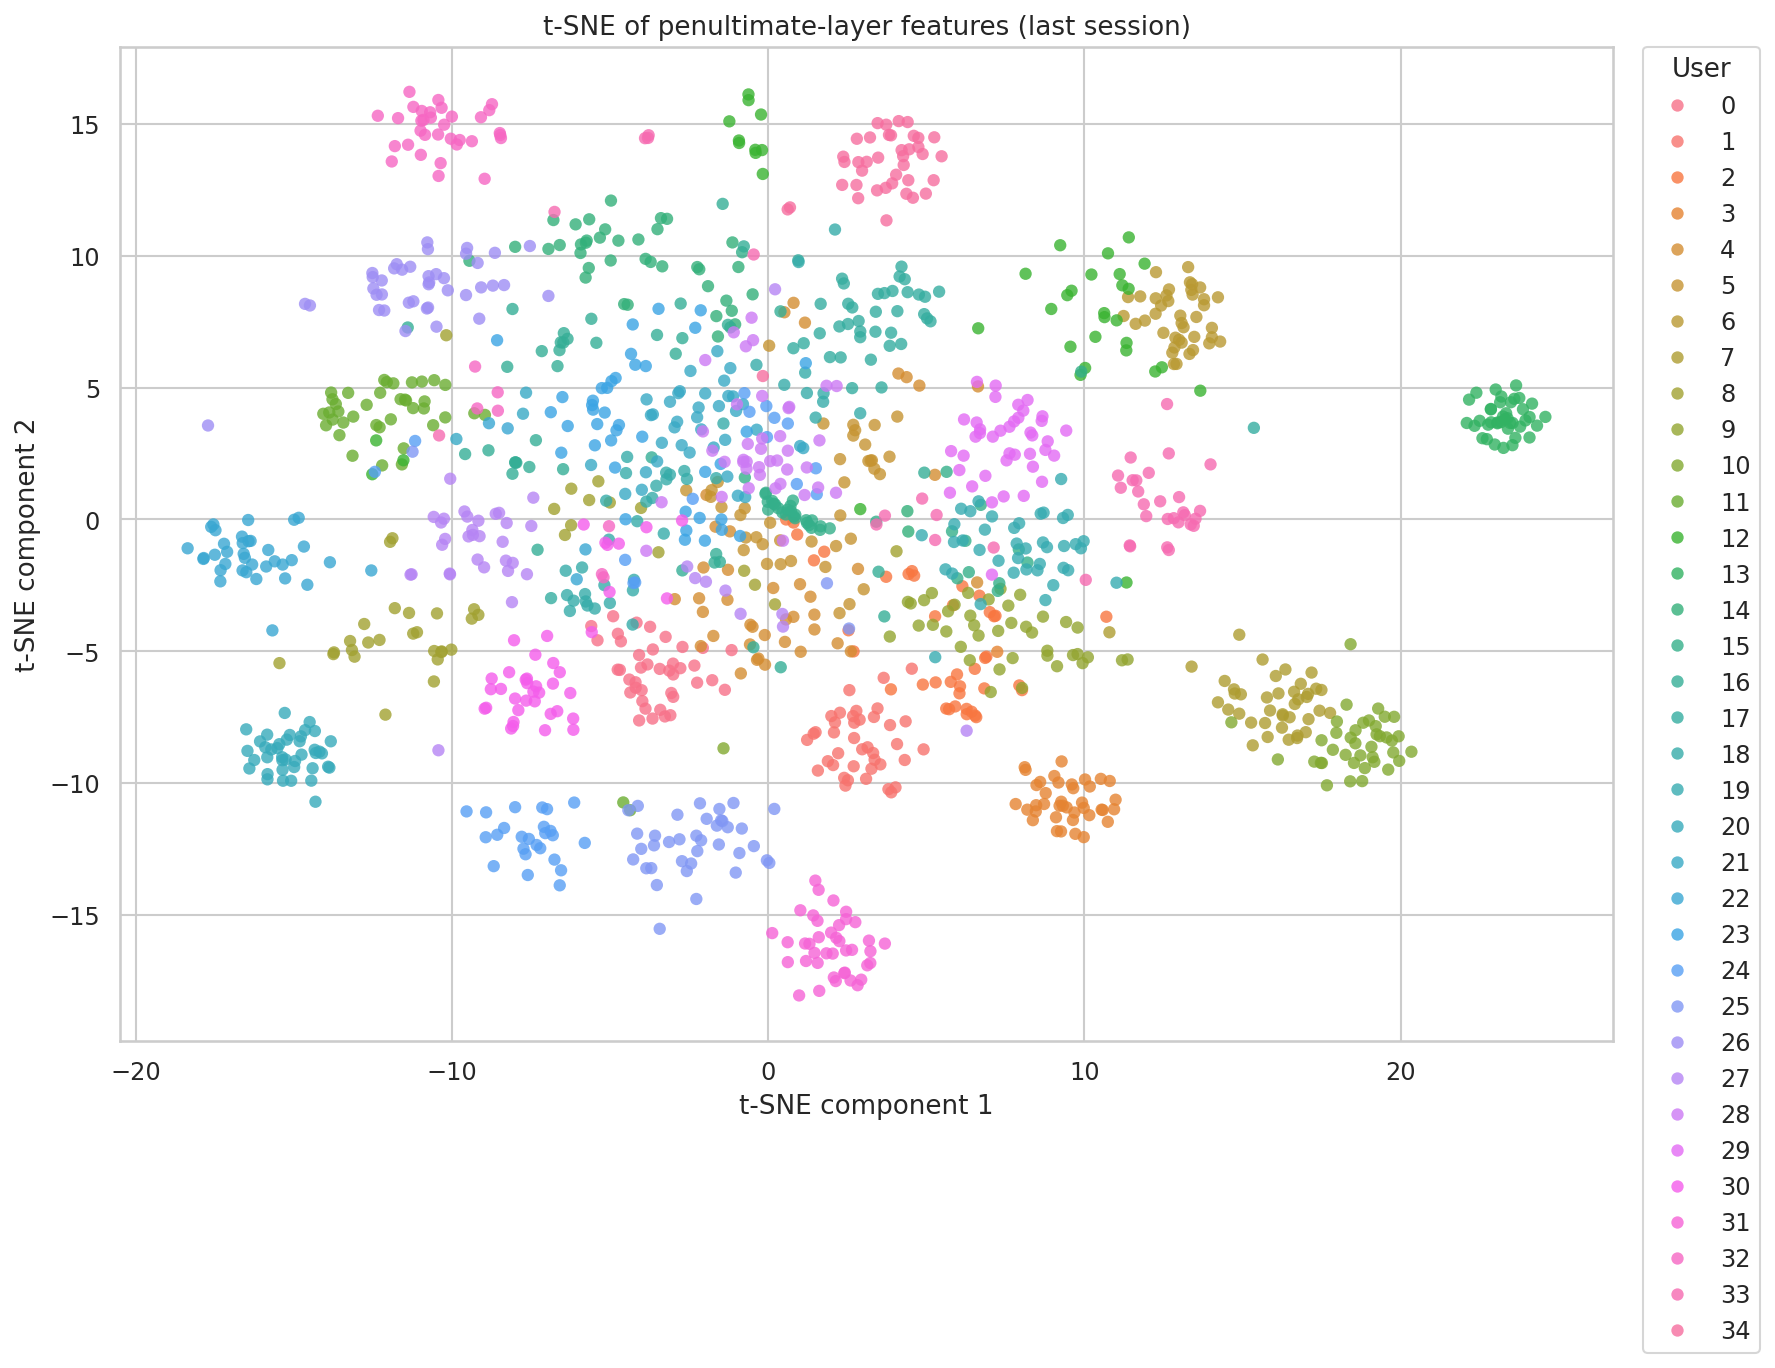

In [8]:
# --- Feature extraction, t-SNE and visualization ---
import pandas as pd
from sklearn.manifold import TSNE

def _find_last_module_for_features(model):
    # Prefer the final linear layer (classifier). Fall back to last Conv2d if none.
    for name, module in reversed(list(model.named_modules())):
        if isinstance(module, nn.Linear):
            return module, 'linear'
    for name, module in reversed(list(model.named_modules())):
        if isinstance(module, nn.Conv2d):
            return module, 'conv'
    raise RuntimeError('Could not find suitable feature module in model')

def extract_penultimate_features(model, loader, device):
    model.eval()
    module, mtype = _find_last_module_for_features(model)
    feats = []
    labs = []

    def hook(module, input, output):
        # input is a tuple; take the first element
        x = input[0].detach().cpu().numpy()
        # flatten per-sample to 2D [batch, features]
        x = x.reshape(x.shape[0], -1)
        feats.append(x)

    handle = module.register_forward_hook(hook)
    with torch.inference_mode():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            _ = model(inputs)  # hook will capture the module input
            labs.append(labels.detach().cpu().numpy())
    handle.remove()
    feats = np.concatenate(feats, axis=0) if len(feats) > 0 else np.empty((0,0))
    labs = np.concatenate(labs, axis=0) if len(labs) > 0 else np.empty((0,))
    return feats, labs

# Extract features for train and test sets (use trained best model)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
else:
    print('Warning: best model state not available; using current model weights')

print('Extracting train features...')
train_feats, train_labels = extract_penultimate_features(model, train_loader, device)
print('Extracting test features...')
test_feats, test_labels = extract_penultimate_features(model, test_loader, device)

# Combine train+test for visualization (or choose only test if preferred)
# feats = np.concatenate([train_feats, test_feats], axis=0) if train_feats.size else test_feats
# labels = np.concatenate([train_labels, test_labels], axis=0) if train_labels.size else test_labels
feats = test_feats
labels = test_labels

print(f'Features shape: {feats.shape}, Labels shape: {labels.shape}')

# Run t-SNE (may take a while on large feature sets)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
feats_2d = tsne.fit_transform(feats)
df_feats = pd.DataFrame({
    'tsne_0': feats_2d[:, 0],
    'tsne_1': feats_2d[:, 1],
    'User': labels,
})

# Plot t-SNE colored by user with one unique color per user
unique_users = np.sort(df_feats['User'].unique())
palette = sns.color_palette('husl', n_colors=len(unique_users))
palette_map = dict(zip(unique_users, palette))

plt.figure(figsize=(12, 9), dpi=150)
sns.set_theme(style='whitegrid', font_scale=1.05)
ax = sns.scatterplot(
    data=df_feats,
    x='tsne_0',
    y='tsne_1',
    hue='User',
    hue_order=unique_users,
    palette=palette_map,
    s=35,
    linewidth=0,
    alpha=0.8,
    legend='full',
)

ax.set_title('t-SNE of penultimate-layer features (last session)')
ax.set_xlabel('t-SNE component 1')
ax.set_ylabel('t-SNE component 2')
ax.legend(title='User', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.0, ncol=1)
plt.tight_layout()
plt.show()

## Load frequency trained models and use T-SNE

Carregando dados dos usuarios:   0%|          | 0/35 [00:00<?, ?it/s]

Carregando dados dos usuarios: 100%|██████████| 35/35 [04:03<00:00,  6.95s/it]


Preparing test data without subbands...
X_test_freq: torch.Size([1680, 9, 250]), Y_test_freq (freq): torch.Size([1680])
Num users in test set: 35
Loaded checkpoint keys: odict_keys(['conv_temporal.weight', 'bnorm_temporal.weight', 'bnorm_temporal.bias', 'bnorm_temporal.running_mean', 'bnorm_temporal.running_var', 'bnorm_temporal.num_batches_tracked', 'conv_spatial.parametrizations.weight.original', 'bnorm_1.weight', 'bnorm_1.bias', 'bnorm_1.running_mean', 'bnorm_1.running_var', 'bnorm_1.num_batches_tracked', 'conv_separable_depth.weight', 'conv_separable_point.weight', 'bnorm_2.weight', 'bnorm_2.bias', 'bnorm_2.running_mean', 'bnorm_2.running_var', 'bnorm_2.num_batches_tracked', 'final_layer.conv_classifier.weight', 'final_layer.conv_classifier.bias'])
Model loaded successfully from /home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject/louo_experiments/models/eegnet/best_model.pth
Extracting test features from loaded model...
Features shape: (1680, 112), Labels shape: (1680,)
R

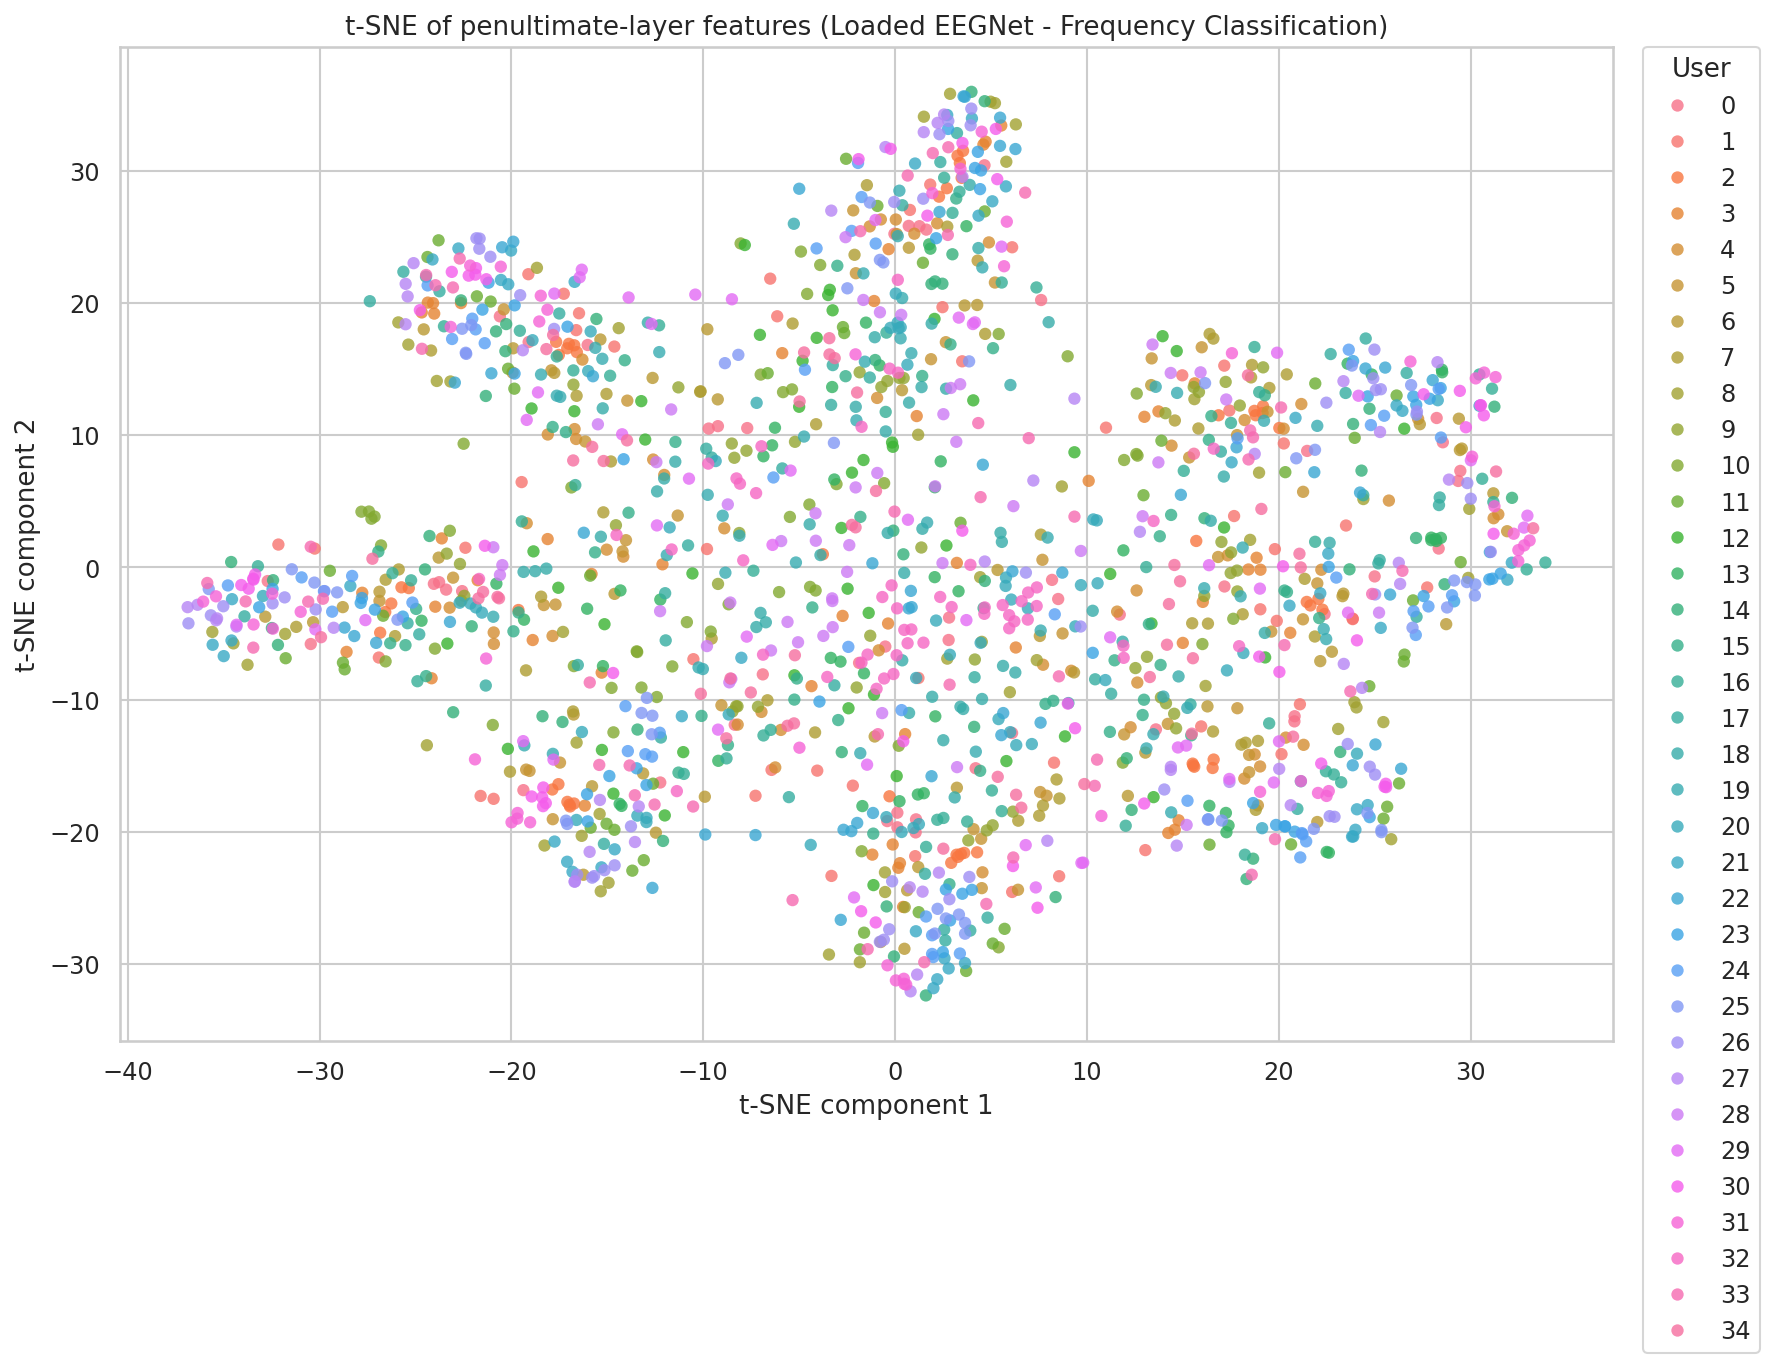

Loaded Model Test Accuracy (Frequency Classification): 0.9244


In [10]:
# --- Load best_model.pth (trained on frequencies) and run t-SNE analysis ---
import os

model_path = "/home/mateuschinelatto/Experiments/ssvep-bci-nn/cross-subject/louo_experiments/models/eegnet/best_model.pth"
if not os.path.exists(model_path):
    print(f"Model file not found at: {os.path.abspath(model_path)}")
else:
    all_data_freq = load_data_from_users(
        users=users,
        dataset_path="/home/mateuschinelatto/Experiments/data/benchmark/",
        visual_delay=delay,
        filter_bandpass=True,
        apply_car=True,
        car_reference_channels=occipital_electrodes,
        car_target_channels=occipital_electrodes,
        sample_rate=sample_rate,
        freq_cut_low=6,
        freq_cut_high=50,
        filter_order=10,
    )
    # Prepare test data WITHOUT subbands (matching training script format)
    from ssvep_shared import filter_signals_subbands

    print("Preparing test data without subbands...")
    test_data_no_subbands = []
    test_labels_freq = []
    test_labels_user = []

    # Load frequency information for training
    freq_data = load_freq_phase()
    frequencias = freq_data[0]
    frequencias_desejadas = frequencias[:8]  # First 8 frequencies
    indices_freq = [np.where(frequencias == freq)[0][0] for freq in frequencias_desejadas]

    # Prepare test data from all sessions, without subbands, with both freq and user labels
    for user_idx, user_data in enumerate(all_data_freq):
        test_trials = user_data  # All sessions

        for freq_idx in indices_freq:
            for trial_idx in range(user_data.shape[-1]):  # Iterate over all trials/sessions
                signal = test_trials[occipital_electrodes, :tamanho_da_janela, freq_idx, trial_idx]
                # Directly use signal without subband filtering
                test_data_no_subbands.append(signal)  # (channels, samples)
                # Track both frequency and user labels
                freq_label = np.where(indices_freq == freq_idx)[0][0]
                test_labels_freq.append(freq_label)
                test_labels_user.append(user_idx)

    X_test_freq = torch.tensor(np.array(test_data_no_subbands), dtype=torch.float32).to(device)
    Y_test_freq = torch.tensor(test_labels_freq, dtype=torch.long).to(device)

    print(f"X_test_freq: {X_test_freq.shape}, Y_test_freq (freq): {Y_test_freq.shape}")
    print(f"Num users in test set: {len(set(test_labels_user))}")


    # Create test loader
    test_loader_freq = DataLoader(TensorDataset(X_test_freq, Y_test_freq), batch_size=BATCH_SIZE_EVAL, shuffle=False)

    # Load the checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    print(f"Loaded checkpoint keys: {checkpoint.keys() if isinstance(checkpoint, dict) else 'state_dict'}")

    # Create a fresh plain EEGNet model (without subband wrapper)
    loaded_model = EEGNet(
        n_chans=len(occipital_electrodes),
        n_outputs=len(frequencias_desejadas),
        n_times=tamanho_da_janela,
        kernel_length=(sample_rate // 2),
        F1=8,
        D=2,
        drop_prob=0.25,
    ).to(device)

    if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
        loaded_model.load_state_dict(checkpoint['state_dict'])
    elif isinstance(checkpoint, dict):
        loaded_model.load_state_dict(checkpoint)
    else:
        loaded_model.load_state_dict(checkpoint)

    loaded_model.eval()
    print(f"Model loaded successfully from {model_path}")

    # Extract features from test set using the loaded model
    print('Extracting test features from loaded model...')
    loaded_test_feats, loaded_test_labels = extract_penultimate_features(loaded_model, test_loader_freq, device)

    print(f'Features shape: {loaded_test_feats.shape}, Labels shape: {loaded_test_labels.shape}')

    # Run t-SNE on the loaded model's features
    print('Running t-SNE on loaded model features...')
    tsne_loaded = TSNE(n_components=2, perplexity=30, random_state=42)
    loaded_feats_2d = tsne_loaded.fit_transform(loaded_test_feats)
    df_loaded_feats = pd.DataFrame({
        'tsne_0': loaded_feats_2d[:, 0],
        'tsne_1': loaded_feats_2d[:, 1],
        'User': np.array(test_labels_user),
    })

    # Plot t-SNE for loaded model colored by User
    unique_users_freq = np.sort(df_loaded_feats['User'].unique())
    palette = sns.color_palette('husl', n_colors=len(unique_users_freq))
    palette_map = dict(zip(unique_users_freq, palette))

    plt.figure(figsize=(12, 9), dpi=150)
    sns.set_theme(style='whitegrid', font_scale=1.05)
    ax = sns.scatterplot(
        data=df_loaded_feats,
        x='tsne_0',
        y='tsne_1',
        hue='User',
        hue_order=unique_users_freq,
        palette=palette_map,
        s=35,
        linewidth=0,
        alpha=0.8,
        legend='full',
    )

    ax.set_title(f't-SNE of penultimate-layer features (Loaded EEGNet - Frequency Classification)')
    ax.set_xlabel('t-SNE component 1')
    ax.set_ylabel('t-SNE component 2')
    ax.legend(title='User', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.0, ncol=1)
    plt.tight_layout()
    plt.show()

    # Compute and display test accuracy
    all_loaded_preds = []
    all_loaded_labels = []
    with torch.inference_mode():
        for inputs, labels in test_loader_freq:
            outputs = loaded_model(inputs)
            _, preds = torch.max(outputs, 1)
            all_loaded_preds.extend(preds.cpu().numpy())
            all_loaded_labels.extend(labels.cpu().numpy())

    all_loaded_preds = np.array(all_loaded_preds)
    all_loaded_labels = np.array(all_loaded_labels)
    loaded_test_acc = accuracy_score(all_loaded_labels, all_loaded_preds)
    print(f"Loaded Model Test Accuracy (Frequency Classification): {loaded_test_acc:.4f}")


In [9]:
# --- Plot t-SNE colored by Frequency ---
print('Plotting t-SNE colored by Frequency...')
df_loaded_feats_freq = pd.DataFrame({
    'tsne_0': loaded_feats_2d[:, 0],
    'tsne_1': loaded_feats_2d[:, 1],
    'Frequency': np.array(test_labels_freq),
})

# Plot t-SNE for loaded model colored by Frequency
unique_freqs = np.sort(df_loaded_feats_freq['Frequency'].unique())
palette_freq = sns.color_palette('husl', n_colors=len(unique_freqs))
palette_map_freq = dict(zip(unique_freqs, palette_freq))

plt.figure(figsize=(12, 9), dpi=150)
sns.set_theme(style='whitegrid', font_scale=1.05)
ax = sns.scatterplot(
    data=df_loaded_feats_freq,
    x='tsne_0',
    y='tsne_1',
    hue='Frequency',
    # hue_order=unique_freqs,
    # palette=palette_map_freq,
    s=35,
    linewidth=0,
    alpha=0.8,
    legend='full',
)

ax.set_title(f't-SNE of penultimate-layer features (Loaded EEGNet - Colored by Frequency)')
ax.set_xlabel('t-SNE component 1')
ax.set_ylabel('t-SNE component 2')
ax.legend(title='Frequency Index', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.0, ncol=1)
plt.tight_layout()
plt.show()


Plotting t-SNE colored by Frequency...


NameError: name 'loaded_feats_2d' is not defined